# Identical Machine Job Scheduling

## Environmnet setup

In [67]:
from build_instances import InstanceHandler, UniformInstance, SmallBigInstance
import matplotlib.pyplot as plt
import numpy as np

folder_path_output = "./output"
folder_path_instances = "./instances/identical_job_scheduling"

instance_handler = InstanceHandler(folder_path_instances)

## Analysis

### Single instance

In [68]:
instance = UniformInstance(100, 10, 1, 1000, 42)
# instance = UniformInstance(100, 20, 1, 99, 45)
# instance = SmallBigInstance(900, 1, 9, 100, 80, 99, 150, 63)
epsilon = 0.005

n_jobs, n_machines, processing_times, OPT_exact = instance_handler.fetch(instance, False)

instance_name = instance.filename().replace(".txt", "")

Normalization

In [69]:
# T_opt = max(max(processing_times), sum(processing_times) / n_machines)
T_opt = sum(processing_times) / n_machines
normalized_processing_times = np.array(processing_times) / T_opt

Picking epsilon

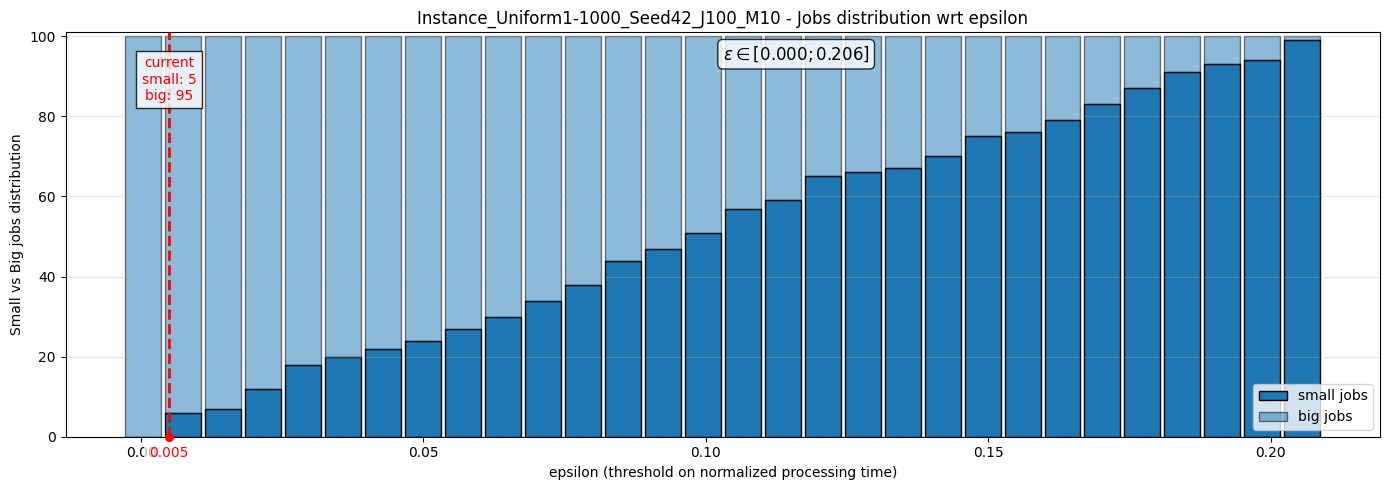

In [70]:
epsilon_min, epsilon_max = min(normalized_processing_times), max(normalized_processing_times)

epsilon_values = np.linspace(epsilon_min, epsilon_max, 30)
small_counts = np.array([(normalized_processing_times < e).sum() for e in epsilon_values])
big_counts = n_jobs - small_counts

plt.figure(figsize=(14, 5))
width = (epsilon_values[1] - epsilon_values[0]) * 0.9

# Plot small vs big jobs distribution wrt epsilon
plt.bar(epsilon_values, small_counts, width=width,  color='C0', edgecolor='k', label='small jobs')
plt.bar(epsilon_values, big_counts, width=width, bottom=small_counts, alpha=0.5, color='C0', edgecolor='k', label='big jobs')
plt.xlabel('epsilon (threshold on normalized processing time)')
plt.ylabel('Small vs Big jobs distribution')
plt.title(f"{instance_name} - Jobs distribution wrt epsilon")
plt.ylim(0, n_jobs + 1)
plt.grid(axis='y', alpha=0.3)
plt.legend()

# Add annotation for big and small jobs
ax = plt.gca()
annotation_epsilon_range = f"$\epsilon \in [{epsilon_min:.3f}; {epsilon_max:.3f}]$"

ax.text(0.5, 0.97, annotation_epsilon_range, transform=ax.transAxes,
  fontsize=12, verticalalignment='top',
  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# highlight current epsilon and show its counts
plt.axvline(epsilon, color='red', linestyle='--', linewidth=2, label=f'epsilon = {epsilon:.3f}')
curr_small = int((normalized_processing_times < epsilon).sum())
curr_big = n_jobs - curr_small
plt.text(epsilon, n_jobs*0.95, f"current\nsmall: {curr_small}\nbig: {curr_big}",
     color='red', ha='center', va='top', bbox=dict(facecolor='white', alpha=0.8))
current_ax = plt.gca()
# red marker on the x-axis at the current epsilon
current_ax.scatter([epsilon], [0], color='red', s=30, zorder=10, clip_on=False)
# current epsilon label below the x-axis highlighted in red
current_ax.text(epsilon, -0.022, f"{epsilon:.3f}", color='red', ha='center', va='top',
                    transform=current_ax.get_xaxis_transform(), fontsize=10,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()

Processing times distribution

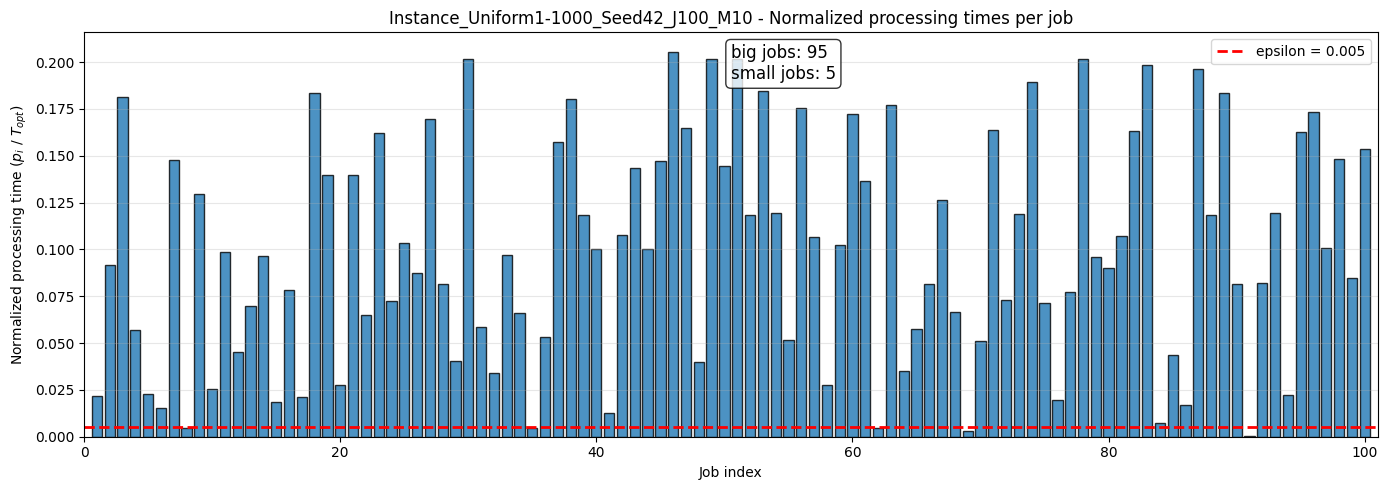

In [71]:
plt.figure(figsize=(14, 5))

# Plot normalized processing times
x = np.arange(1, n_jobs + 1)
plt.bar(x, normalized_processing_times, color='C0', edgecolor='k', alpha=0.8)
plt.xlabel('Job index')
plt.ylabel('Normalized processing time ($p_i$ / $T_{opt}$)')
plt.title(f"{instance_name} - Normalized processing times per job")
plt.grid(axis='y', alpha=0.3)
plt.xlim(0, n_jobs+1)
plt.tight_layout()

# Plot epsilon threshold
plt.axhline(epsilon, color='red', linestyle='--', linewidth=2, label=f'epsilon = {epsilon:.3f}')
plt.legend()

# Add annotation for big and small jobs
ax = plt.gca()
small = int((normalized_processing_times < epsilon).sum())
big = int((normalized_processing_times >= epsilon).sum())
annotation_jobs = f"big jobs: {big}\nsmall jobs: {small}"

ax.text(0.5, 0.97, annotation_jobs, transform=ax.transAxes,
  fontsize=12, verticalalignment='top',
  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

results analysis

In [72]:
import pandas as pd

df_results = pd.read_csv(f"{folder_path_output}/latest_identical_job_scheduling_random_instances.csv")
df_results

,instance,epsilon_range,n_machines,n_jobs,epsilon,branching_rule,node_selection,profiling_mode,rounding_rule,lower_bound,best_solution,best_bound,runtime,depth,nodes_explored,terminate,number_of_nodes_for_optimality,optimal_solution,opt_gap
0,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.002001,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,4757,4747.9,0.213498,90,92,True,92,4748.0,0.001892
1,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.001000,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,4757,4747.9,9.767249,94,2980,True,2980,4748.0,0.001892
2,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.004004,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,4762,4747.9,0.193528,85,87,True,87,4748.0,0.002940
3,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.002000,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,4758,4747.9,2.309818,93,813,True,813,4748.0,0.002102
4,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.010025,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,4794,4747.9,0.139639,61,63,True,63,4748.0,0.009595
5,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.005000,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,4795,4747.9,0.173506,72,74,True,74,4748.0,0.009802
6,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.020100,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,4826,4747.9,0.071572,37,39,True,39,4748.0,0.016162
7,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.010000,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,4809,4747.9,0.078161,39,41,True,41,4748.0,0.012685
8,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.040400,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,4909,4747.9,0.024068,11,13,True,13,4748.0,0.032797
9,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.020000,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,4886,4747.9,0.012975,7,9,True,9,4748.0,0.028244


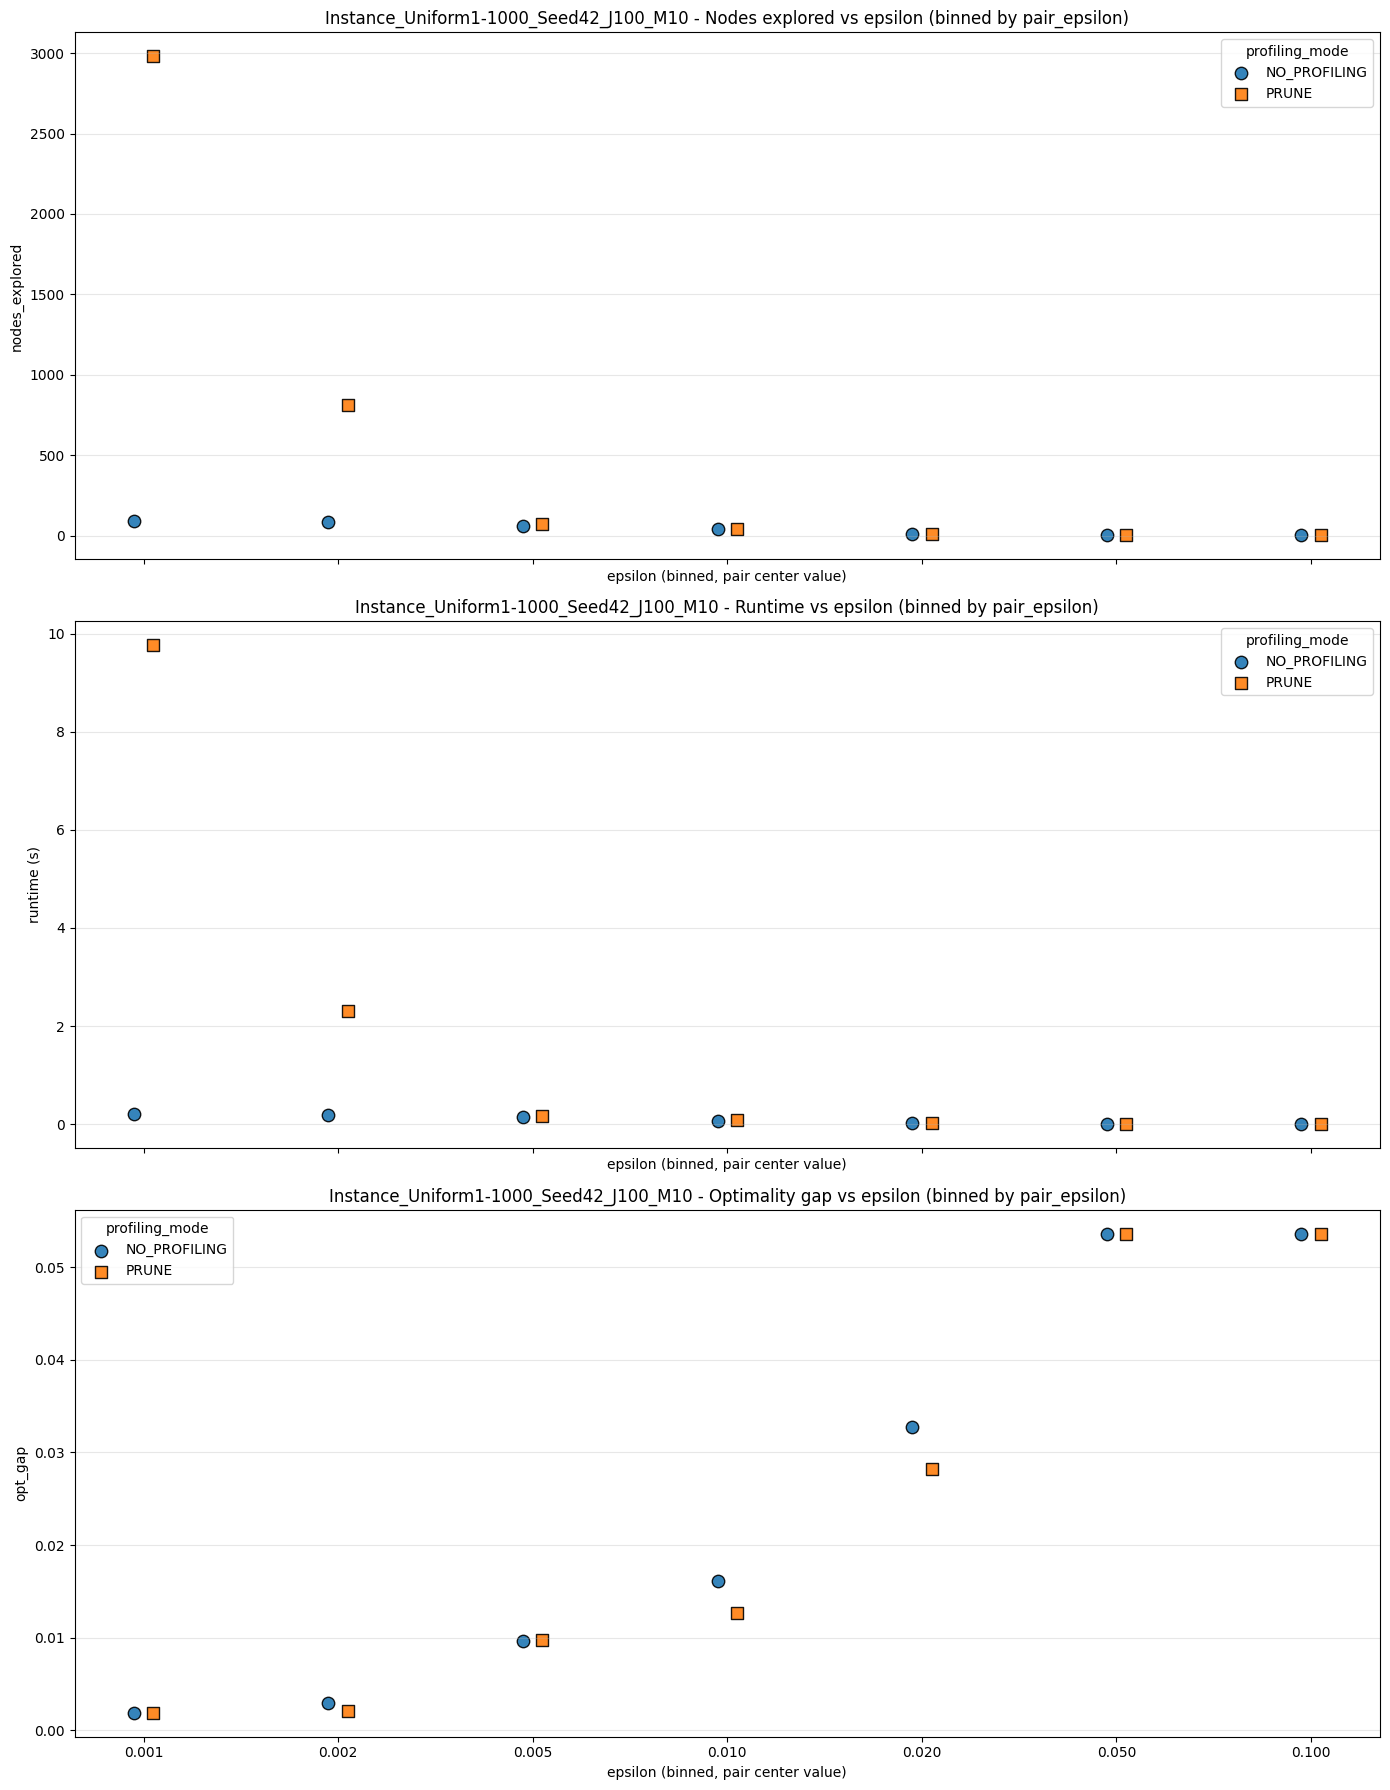

In [83]:
# two-panel scatter: left = nodes_explored, right = runtime
df = df_results.reset_index(drop=True).copy()
df['pair'] = (df.index // 2)
pair_eps = df.iloc[1::2]['epsilon'].reset_index(drop=True)
df['pair_epsilon'] = df['pair'].map(pair_eps)

# bin centers / edges (same logic as before)
bin_centers = pair_eps.values
edges = np.empty(len(bin_centers) + 1, dtype=float)
if len(bin_centers) > 1:
  edges[1:-1] = (bin_centers[:-1] + bin_centers[1:]) / 2
  edges[0] = bin_centers[0] - (bin_centers[1] - bin_centers[0]) / 2
  edges[-1] = bin_centers[-1] + (bin_centers[-1] - bin_centers[-2]) / 2
else:
  delta = 1e-6
  edges[0] = bin_centers[0] - delta
  edges[1] = bin_centers[0] + delta

df['epsilon_bin'] = np.digitize(df['pair_epsilon'], edges) - 1

modes_unique = df['profiling_mode'].unique()
n_modes = len(modes_unique)
marker_list = markers if 'markers' in globals() else ['o','s','^','D','P','X','*']
colors_map = plt.cm.tab10(np.linspace(0, 1, max(10, n_modes)))[:n_modes]
bin_offsets = np.linspace(-0.05, 0.05, n_modes)

fig, (ax_nodes, ax_time, ax_opt) = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

for i, mode in enumerate(modes_unique):
  df_m = df[df['profiling_mode'] == mode]
  x = df_m['epsilon_bin'].values + bin_offsets[i]
  ax_nodes.scatter(x, df_m['nodes_explored'].values,
           label=mode, marker=marker_list[i % len(marker_list)],
           color=colors_map[i], edgecolor='k', s=80, alpha=0.9)
  ax_time.scatter(x, df_m['runtime'].values,
          label=mode, marker=marker_list[i % len(marker_list)],
          color=colors_map[i], edgecolor='k', s=80, alpha=0.9)
  ax_opt.scatter(x, df_m['opt_gap'].values,
          label=mode, marker=marker_list[i % len(marker_list)],
          color=colors_map[i], edgecolor='k', s=80, alpha=0.9)

# nodes explored plot
ax_nodes.set_xlabel('epsilon (binned, pair center value)')
ax_nodes.set_ylabel('nodes_explored')
ax_nodes.set_title(f"{instance_name} - Nodes explored vs epsilon (binned by pair_epsilon)")
ax_nodes.grid(axis='y', alpha=0.3)
ax_nodes.legend(title='profiling_mode')

# runtime plot
ax_time.set_xlabel('epsilon (binned, pair center value)')
ax_time.set_ylabel('runtime (s)')
ax_time.set_title(f"{instance_name} - Runtime vs epsilon (binned by pair_epsilon)")
ax_time.grid(axis='y', alpha=0.3)
ax_time.legend(title='profiling_mode')

# optimality gap plot
ax_opt.set_xlabel('epsilon (binned, pair center value)')
ax_opt.set_ylabel('opt_gap')
ax_opt.set_title(f"{instance_name} - Optimality gap vs epsilon (binned by pair_epsilon)")
ax_opt.grid(axis='y', alpha=0.3)
ax_opt.legend(title='profiling_mode')

# show only bins that actually contain points, label ticks with pair centers
used_bins = np.sort(df['epsilon_bin'].unique())
xticks = used_bins
xtick_labels = [f"{bin_centers[b]:.3f}" for b in used_bins]
ax_nodes.set_xticks(xticks)
ax_nodes.set_xticklabels(xtick_labels, rotation=45)
ax_time.set_xticks(xticks)
ax_time.set_xticklabels(xtick_labels, rotation=45)

plt.tight_layout()
plt.show()

In [80]:
df

,instance,epsilon_range,n_machines,n_jobs,epsilon,branching_rule,node_selection,profiling_mode,rounding_rule,lower_bound,...,runtime,depth,nodes_explored,terminate,number_of_nodes_for_optimality,optimal_solution,opt_gap,pair,pair_epsilon,epsilon_bin
0,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.002001,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,...,0.213498,90,92,True,92,4748.0,0.001892,0,0.001,0
1,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.001000,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,...,9.767249,94,2980,True,2980,4748.0,0.001892,0,0.001,0
2,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.004004,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,...,0.193528,85,87,True,87,4748.0,0.002940,1,0.002,1
3,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.002000,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,...,2.309818,93,813,True,813,4748.0,0.002102,1,0.002,1
4,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.010025,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,...,0.139639,61,63,True,63,4748.0,0.009595,2,0.005,2
5,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.005000,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,...,0.173506,72,74,True,74,4748.0,0.009802,2,0.005,2
6,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.020100,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,...,0.071572,37,39,True,39,4748.0,0.016162,3,0.010,3
7,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.010000,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,...,0.078161,39,41,True,41,4748.0,0.012685,3,0.010,3
8,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.040400,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,...,0.024068,11,13,True,13,4748.0,0.032797,4,0.020,4
9,Uniform1-1000_Seed42_J100_M10,"[0.000421, 0.205565]",10,100,0.020000,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,...,0.012975,7,9,True,9,4748.0,0.028244,4,0.020,4


In [75]:
# display even rows (0-based: rows 0,2,4,...)
df.iloc[1::2]['epsilon']

1     0.001
3     0.002
5     0.005
7     0.010
9     0.020
11    0.050
13    0.100
Name: epsilon, dtype: float64